In [1]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats=['svg']
%load_ext autoreload
%autoreload 2

# Generic packages
import numpy as np 
from os import listdir


# Machine Learning
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.cluster import KMeans, MiniBatchKMeans

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from tqdm.notebook import tqdm

from numpy import trapz
from scipy.signal import savgol_filter
import torch


from AutoencoderAPI.utils.files import open_object
from AutoencoderAPI.utils.plot import plot_hist
from AutoencoderAPI import autoencoder as auto
from AutoencoderAPI.filterAutoencoder import filterAutoencoder

### Functions

#### Load traces

In [2]:
class build_dataset:
    def __init__(self, config):
        """
        # __init(config)__

        __init(config)__

            Define parameters to access the dataset

        Parameters
        ----------
            -config (dict) : Parameters (path, signal_size, batch_number) 

        Returns
        -------
            - None
        """
        self.files = listdir(config['path'])
        self.path = config['path']
        self.signal_size = config['signal_size']

        if config['batch_number'] > len(self.files):
            print(f'Batch number too large, was set to {len(self.files)}')
            config['batch_number'] = len(self.files)

        self.batch_split = np.array_split(self.files, config['batch_number'])


    def __getitem__(self,index):
        """
        
        """
        batch = self.batch_split[index]
    
        X = np.concatenate([np.fromfile(f"{self.path}{fileName}",dtype=np.float16).reshape(-1,self.signal_size) for fileName in batch])

        return X

In [3]:
class compare:

    def __init__(self, config):
        
        self.dataset = build_dataset(config)
        self.config = config


    def silhouette_kmean(self, X_list, Title, min_max_cluster, skip):
        min_cluster, max_cluster = min_max_cluster

        eval_cluster = range(min_cluster+1,max_cluster+1)
        scores = np.zeros((len(X_list) , len(eval_cluster)))

        for index, X in enumerate(X_list):

            if skip > 1:
                X = X[::skip]

            X = (X - np.min(X)) / (np.max(X) - np.min(X)) 
            X = np.array(X).reshape(-1,1)
            
            for cluster_index, cluster_number in tqdm(enumerate(eval_cluster), total=len(eval_cluster) , desc=f"{Title[index]}") :
                
                clusters = MiniBatchKMeans(n_clusters=cluster_number, random_state=42, init="k-means++", n_init='auto', batch_size=4096).fit_predict(X)
                scores[index][cluster_index] = silhouette_score(X, clusters)
    
        plt.figure(figsize=(10,5))
        plt.imshow(scores,aspect='auto')#, interpolation="bilinear")
        plt.xlabel('Number of cluster')
        plt.ylabel('Method')
        plt.xticks(np.arange(len(eval_cluster)), labels=eval_cluster)
        plt.yticks(np.arange(len(Title)), labels=Title)
        plt.colorbar()

        for (j,i),label in np.ndenumerate(scores):
            plt.text(i,j,round(label,2),ha='center',va='center')
            plt.text(i,j,round(label,2),ha='center',va='center')

        plt.show()

            

        return eval_cluster, scores



    def max_value(self):

        X_filter = savgol_filter(self.dataset.__getitem__(0), 10, 2)
        feature = np.max(X_filter, axis=1)
        
        if self.config['batch_number'] > 1:
            for batch_index in range(1, self.config['batch_number']):

                X_filter = savgol_filter(self.dataset.__getitem__(batch_index), 20, 2)
                feature = np.append(feature, np.max(X_filter, axis=1))

        return feature

    

    def area(self):

        X_filter = savgol_filter(self.dataset.__getitem__(0), 10, 2)
        feature = trapz(X_filter, dx=1)
        
        if self.config['batch_number'] > 1:
            for batch_index in range(1, self.config['batch_number']):

                X_filter = savgol_filter(self.dataset.__getitem__(batch_index), 20, 2) 
                feature = np.append(feature, trapz(X_filter, dx=1))

        return feature


    def principal_component(self):

        ft = filterAutoencoder('run-2023-08-21-16-17/fold 0')
        accepted, filtered = ft.filtering(self.dataset.__getitem__(0), 5e-4)

        X_filter = savgol_filter(accepted, 20, 2)

        pca = IncrementalPCA(n_components=1, batch_size=100)
        feature = pca.fit_transform(X_filter)

        return feature

    
    def autoencoder(self, model):

        path = f"Autoencoder Log/{model}"
        config_load = open_object(f"{path}/log.bin")

        results = open_object(f"{path}/results.bin")

        network = auto.build_autoencoder(config_load)
        network.load_state_dict(torch.load(f"{path}/model.pt"))
        network.eval()

        X_pytorch = torch.from_numpy(self.dataset.__getitem__(0)).view(-1, 1, config_load['files']['input_dimension']).float()
        feature = network(X_pytorch, encoding=True).detach().numpy().reshape(-1)

        return results['encode']#feature
    
    
    def autoencoderFiltered(self, model):

        path = f"Autoencoder Log/{model}"
        config_load = open_object(f"{path}/log.bin")

        ft = filterAutoencoder(model)
        accepted, filtered = ft.filtering(self.dataset.__getitem__(0), 5e-4)


        network = auto.build_autoencoder(config_load)
        network.load_state_dict(torch.load(f"{path}/model.pt"))
        network.eval()

        X_pytorch = torch.from_numpy(accepted).view(-1, 1, config_load['files']['input_dimension']).float()
        feature = network(X_pytorch, encoding=True).detach().numpy().reshape(-1)

        return feature

In [4]:
config = {
    'path'         : "Datasets/NIST (250)/",#Oxford/", #NIST (250)/", #Oxford/",#
    'signal_size'  : 250,#4096,#496,#496,#250,#800,
    'batch_number' : 1
}

### Experiments

In [5]:
comp = compare(config)

In [6]:
feature_MV = comp.max_value()

In [7]:
feature_AR = comp.area()

In [8]:
feature_PCA = comp.principal_component()

Error when loading file :  [Errno 2] No such file or directory: 'Autoencoder Log/run-2023-08-21-16-17/fold 0/log.bin'


UnboundLocalError: local variable 'object_' referenced before assignment

In [ ]:
feature_AUTO = comp.autoencoder(model='run-2023-08-16-14-13/fold 0')

In [ ]:
feature_AUTO_filtered = comp.autoencoderFiltered(model='run-2023-08-16-14-13/fold 0')

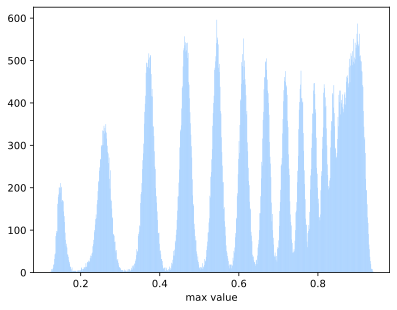

In [ ]:
plot_hist(feature_MV, "max value")

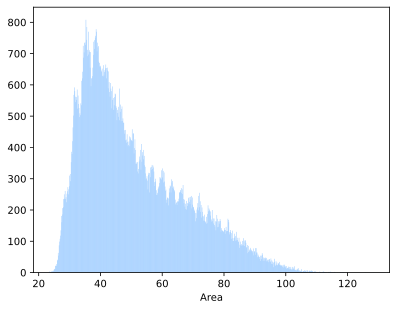

In [ ]:
plot_hist(feature_AR, "Area")

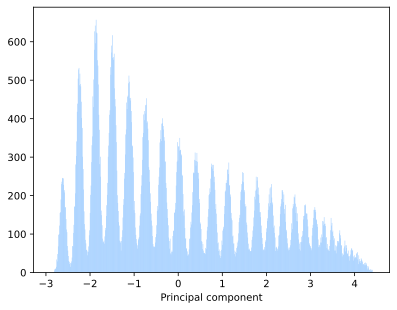

In [ ]:
plot_hist(feature_PCA, "Principal component")

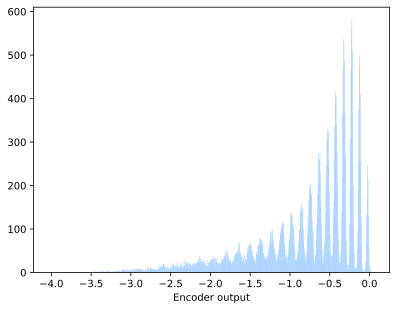

In [ ]:
plot_hist(feature_AUTO, "Encoder output")

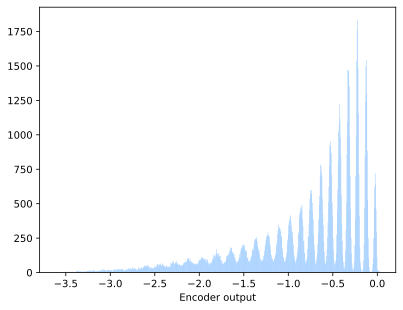

In [ ]:
plot_hist(feature_AUTO_filtered, "Encoder output")

Max Value:   0%|          | 0/15 [00:00<?, ?it/s]

Area:   0%|          | 0/15 [00:00<?, ?it/s]

PCA:   0%|          | 0/15 [00:00<?, ?it/s]

Autoencoder:   0%|          | 0/15 [00:00<?, ?it/s]

Autoencoder filtered:   0%|          | 0/15 [00:00<?, ?it/s]

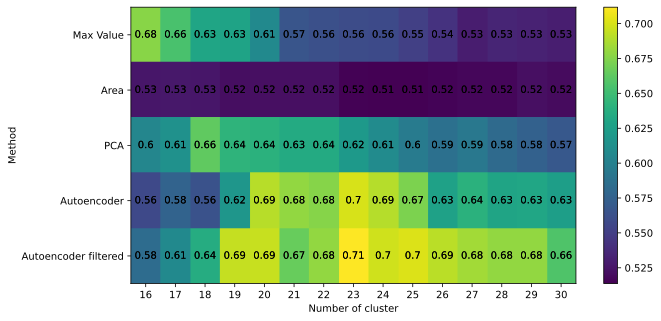

(range(16, 31),
 array([[0.67681324, 0.65514588, 0.62996995, 0.62821608, 0.60770145,
         0.56589933, 0.56228976, 0.55982129, 0.55809191, 0.55141151,
         0.54280786, 0.52987603, 0.53423045, 0.53288621, 0.53063022],
        [0.52534561, 0.52648912, 0.5256403 , 0.52142046, 0.52159715,
         0.52209573, 0.52164127, 0.51508064, 0.51377955, 0.51368513,
         0.51548522, 0.51743499, 0.51704378, 0.52171497, 0.51974382],
        [0.60431191, 0.61397547, 0.66320424, 0.64246493, 0.6399589 ,
         0.63442617, 0.63511863, 0.61990841, 0.6093049 , 0.59573827,
         0.58661711, 0.59307843, 0.58183809, 0.57519298, 0.56859689],
        [0.55761266, 0.5766511 , 0.56330132, 0.61774528, 0.69052029,
         0.67969489, 0.67566609, 0.70001769, 0.68984544, 0.67292362,
         0.62736899, 0.64056802, 0.62898266, 0.63088942, 0.62510192],
        [0.58385718, 0.60797501, 0.63599038, 0.69469225, 0.69485372,
         0.66563284, 0.67988569, 0.71176267, 0.69760579, 0.70107049,
         0.691

In [ ]:
X_list = [feature_MV, feature_AR, feature_PCA, feature_AUTO, feature_AUTO_filtered]
Title = ["Max Value", "Area", "PCA", "Autoencoder", "Autoencoder filtered"]

comp.silhouette_kmean(X_list, Title, min_max_cluster=(15,30), skip=1)